Title

Exploratory Data Analysis of Online Payment Fraud Detection Dataset

link:["https://www.kaggle.com/datasets/jainilcoder/online-payment-fraud-detection?utm_source=chatgpt.com"]

Business Problem Statement

* The organization wants to analyze the dataset to identify patterns, trends, and relationships among variables. The insights obtained from the analysis will help in making data-driven decisions and improving overall business performance.

Objective

• To analyze transaction patterns.

• To identify characteristics of fraudulent transactions.

• To study the impact of transaction amount and transaction type on fraud.

• To detect anomalies and outliers.

• To generate business insights and recommendations.

In [2]:
#Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Observation
* Imported required libraries for data manipulation and visualization.
* Pandas is used for data handling.
* Matplotlib and Seaborn are used for graphical analysis.

In [3]:
#Load Dataset
df=pd.read_csv('onlinefraud.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


Observation:
* The first five records of the dataset were displayed, providing an overview of transaction-related features and fraud indicators.

In [6]:
#Dataset Shape
df.shape

(6362620, 11)

Observation
* Dataset contains 6,362,620 rows and 11 columns.
* The large size of the dataset provides sufficient transaction records for fraud analysis.

In [5]:
#Column Names
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

Observation:

The dataset contains transaction-related features such as transaction amount, transaction type, account balances, and fraud indicators which are useful for fraud analysis.

In [27]:
#Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


Observation:

The dataset contains both numerical and categorical variables. Numerical columns are suitable for statistical analysis, while categorical columns can be used for transaction-type analysis.

In [7]:
#Missing Values
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Observation:
* No missing values were found in any column.
* The dataset is complete and does not require missing value treatment.

In [8]:
#Duplicate Records
df.duplicated().sum()

np.int64(0)

Observation:
* No duplicate records were found in the dataset.
* Each transaction appears to be unique.

In [9]:
#Statistical Summary
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Observation:
* The statistical summary shows significant variation in transaction amounts and account balances.
* The presence of large maximum values suggests possible outliers that require further investigation.

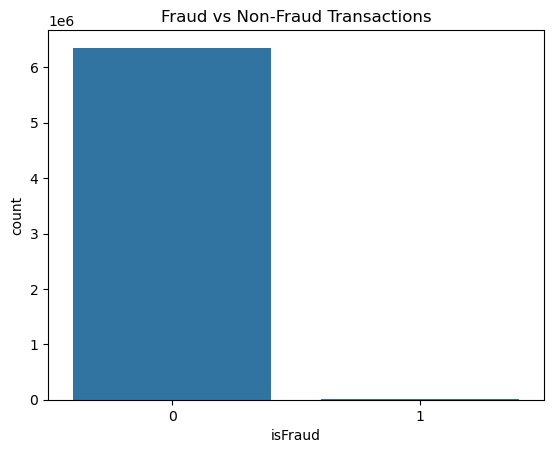

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

#Fraud Distribution
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

Observation:
* Non-fraud transactions dominate the dataset.
* Fraud cases represent a very small percentage.
* Dataset is highly imbalanced.

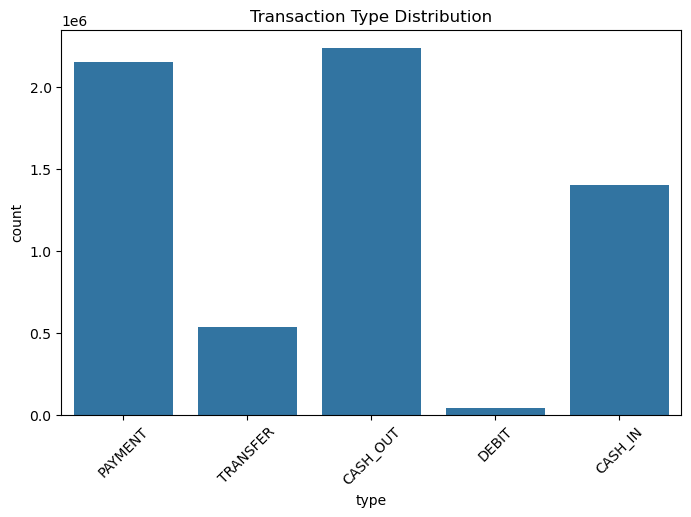

In [11]:
#Transaction Type Distribution

plt.figure(figsize=(8,5))
sns.countplot(x='type', data=df)
plt.xticks(rotation=45)
plt.title("Transaction Type Distribution")
plt.show()

Observation:

* Certain transaction types occur more frequently than others.
* Helps understand customer transaction behavior.

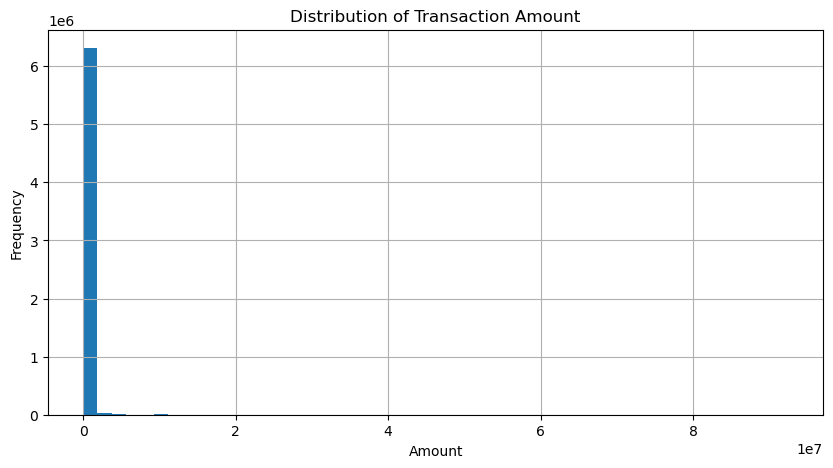

In [12]:
#Histogram of Transaction Amount
plt.figure(figsize=(10,5))
df['amount'].hist(bins=50)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

Observation:
* Most transactions involve smaller amounts.
* Few transactions involve very large amounts.
* Distribution is positively skewed.

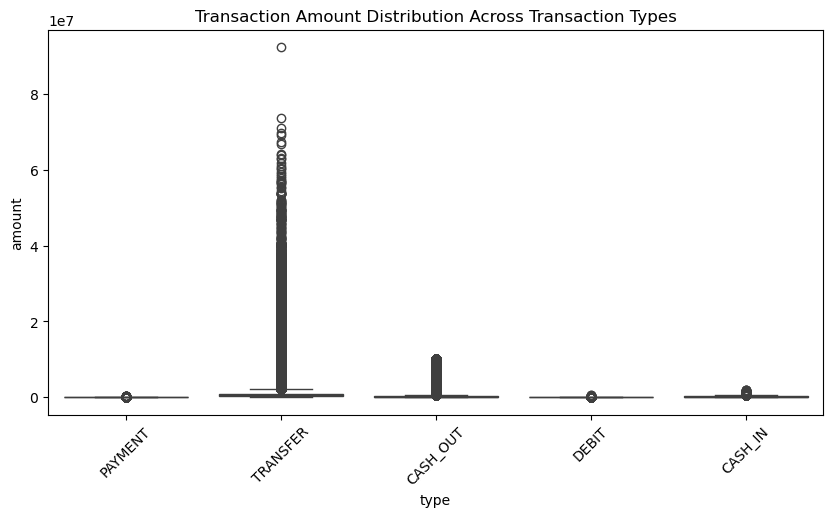

In [28]:
#Boxplot for Amount (Outlier Detection)
plt.figure(figsize=(10,5))
sns.boxplot(x='type', y='amount', data=df)
plt.xticks(rotation=45)
plt.title("Transaction Amount Distribution Across Transaction Types")
plt.show()

Observation:
* Several extreme outliers are present.
* High-value transactions differ significantly from normal transactions.
* Potential fraud cases may exist among outliers.

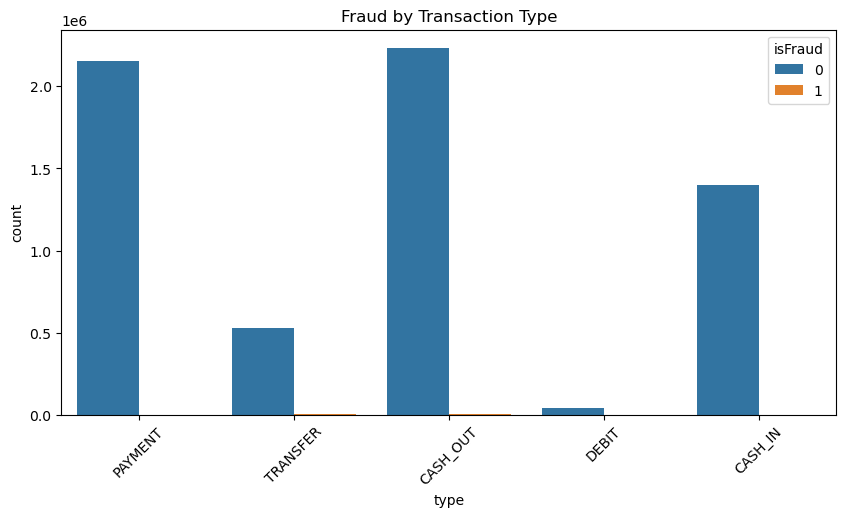

In [14]:
#Fraud by Transaction Type
plt.figure(figsize=(10,5))
sns.countplot(x='type', hue='isFraud', data=df)
plt.xticks(rotation=45)
plt.title("Fraud by Transaction Type")
plt.show()

Observation:
* Fraud occurs mainly in specific transaction types.
* Some transaction categories show almost no fraud activity.

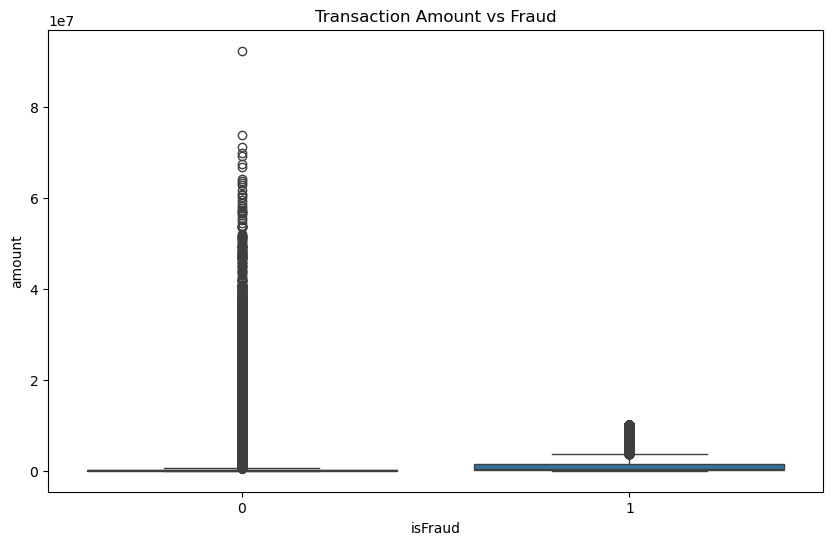

In [15]:
#Amount vs Fraud
plt.figure(figsize=(10,6))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

Observation:

* Fraudulent transactions generally involve larger amounts.
* Transaction amount appears to be an important fraud indicator.

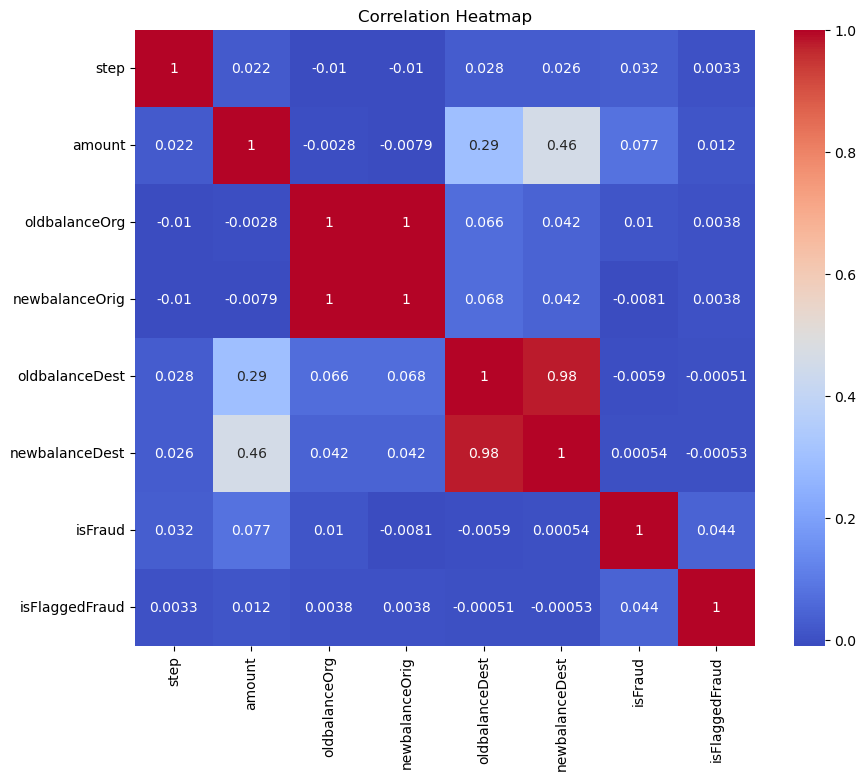

In [16]:
#Correlation Heatmap
plt.figure(figsize=(10,8))

corr = df[['step',
           'amount',
           'oldbalanceOrg',
           'newbalanceOrig',
           'oldbalanceDest',
           'newbalanceDest',
           'isFraud',
           'isFlaggedFraud']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Observation:
* Strong relationships exist between balance-related variables.
* Fraud shows varying degrees of correlation with transaction features.

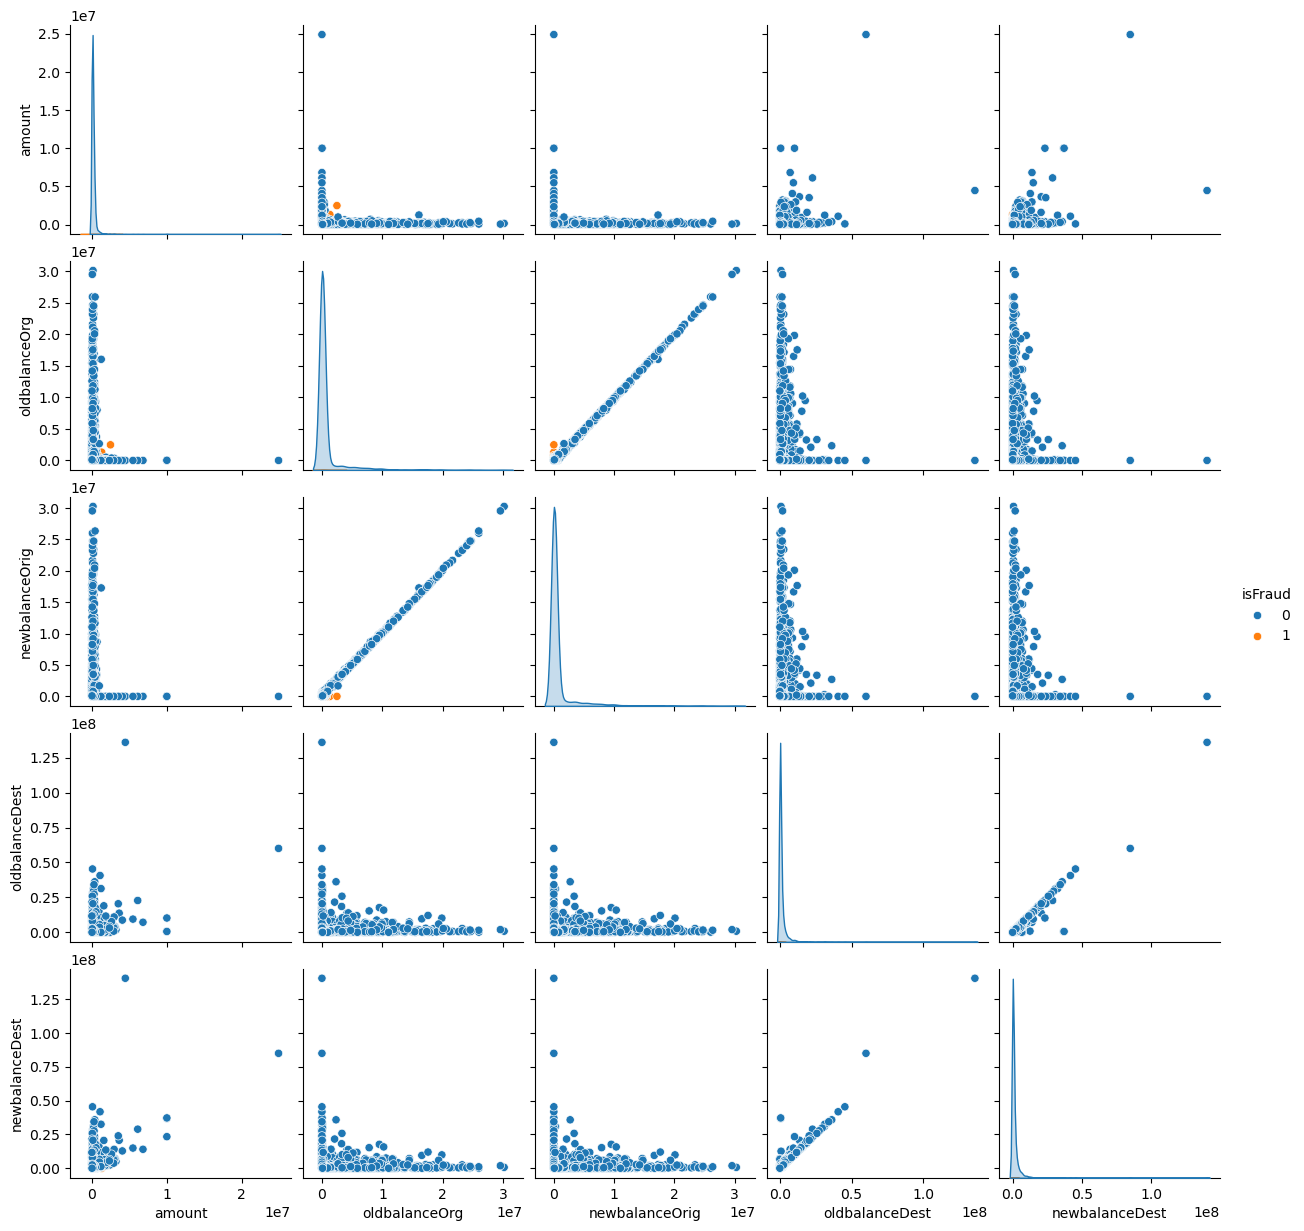

In [17]:
#Pairplot
sample_df = df.sample(5000)

sns.pairplot(
    sample_df[['amount',
               'oldbalanceOrg',
               'newbalanceOrig',
               'oldbalanceDest',
               'newbalanceDest',
               'isFraud']],
    hue='isFraud'
)

plt.show()

Observation:
* Fraud and non-fraud transactions show different patterns.
* Certain balance combinations are more common in fraudulent transactions.

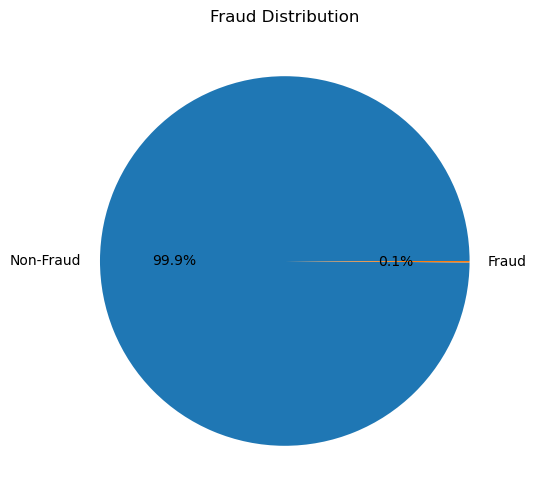

In [18]:
#Pie chart
fraud_counts = df['isFraud'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(fraud_counts,
        labels=['Non-Fraud','Fraud'],
        autopct='%1.1f%%')

plt.title("Fraud Distribution")
plt.show()

Observation:
* Fraud transactions account for a very small proportion of total transactions.
* Class imbalance is clearly visible.

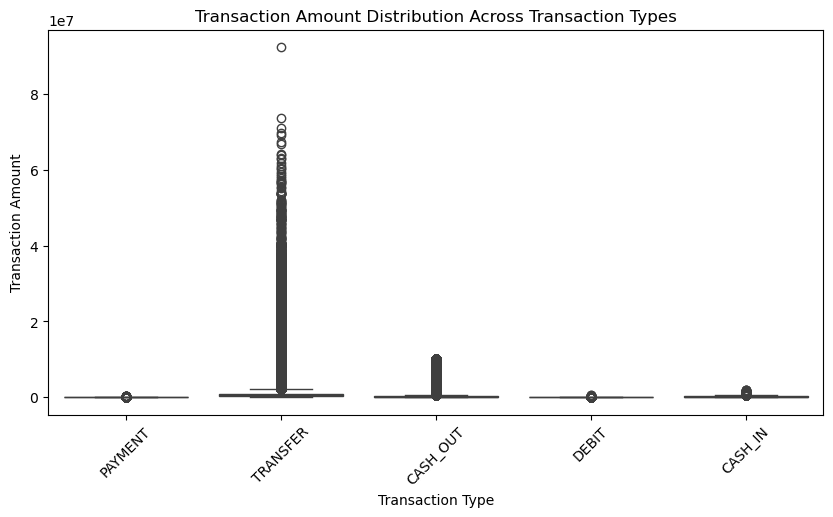

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x='type', y='amount', data=df)
plt.xticks(rotation=45)
plt.title("Transaction Amount Distribution Across Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")
plt.show()

Observation

The boxplot shows that transaction amounts vary significantly across different transaction types...

In [35]:
#Transaction Type Frequency (Value Counts)

df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Observation:
* CASH_OUT and PAYMENT transactions occur most frequently.
* Some transaction types are used much less often.
* Transaction frequency helps understand customer transaction behavior.

In [36]:
#Average Transaction Amount by Type (GroupBy)

df.groupby('type')['amount'].agg(
    ['count','mean','min','max']
).round(2)

,count,mean,min,max
type,,,,
CASH_IN,1399284,168920.24,0.04,1915267.90
CASH_OUT,2237500,176273.96,0.00,10000000.00
DEBIT,41432,5483.67,0.55,569077.51
PAYMENT,2151495,13057.60,0.02,238637.98
TRANSFER,532909,910647.01,2.60,92445516.64


Observation:

* Transaction amounts vary significantly across transaction types.
* Some transaction categories handle larger average transaction values.
* Maximum transaction amounts are extremely high, indicating possible outliers.

In [37]:
#Fraud Analysis by Transaction Type

df.groupby('type')['isFraud'].agg(
    ['count','sum']
)

,count,sum
type,,
CASH_IN,1399284,0
CASH_OUT,2237500,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,532909,4097


Observation:

* Fraud is not evenly distributed across transaction types.
* Certain transaction categories account for most fraudulent activities.
* This information can help prioritize fraud monitoring efforts.

In [38]:
#Pivot Table Analysis

pivot_table = pd.pivot_table(
    df,
    values='amount',
    index='type',
    columns='isFraud',
    aggfunc='mean'
)

pivot_table

isFraud,0,1
type,,
CASH_IN,168920.242004,NaN
CASH_OUT,173917.155751,1.455103e+06
DEBIT,5483.665314,NaN
PAYMENT,13057.604660,NaN
TRANSFER,906229.007812,1.480892e+06


Observation:

* Average transaction amounts differ between fraud and non-fraud transactions.
* Fraudulent transactions tend to involve higher transaction values in some categories.
* The pivot table highlights transaction types with elevated fraud risk.

In [39]:
#Fraud Percentage Analysis

fraud_percentage = pd.crosstab(
    df['type'],
    df['isFraud'],
    normalize='index'
)*100

fraud_percentage.round(2)

isFraud,0,1
type,,
CASH_IN,100.00,0.00
CASH_OUT,99.82,0.18
DEBIT,100.00,0.00
PAYMENT,100.00,0.00
TRANSFER,99.23,0.77


Key Insights

• Fraud cases are extremely rare compared to normal transactions.

• Fraud is concentrated in specific transaction types.

• Large transaction amounts are more likely to be fraudulent.

• Balance-related variables strongly influence fraud behavior.

• Significant outliers exist in transaction amounts.

• Fraudulent transactions exhibit distinct transaction patterns.

• Dataset is highly imbalanced, requiring special attention during fraud analysis.

Observation

The boxplot shows that transaction amounts vary significantly across different transaction types. Some transaction categories contain higher-value transactions and exhibit a larger spread of values, indicating greater variability in transaction behavior. Several outliers are also visible, representing unusually large transactions.

Conclusion

The exploratory data analysis successfully identified important patterns associated with fraudulent transactions. Fraud cases are relatively rare but are concentrated in particular transaction types and often involve higher transaction amounts. Balance-related features showed strong relationships and can play a significant role in fraud detection. These findings can help financial institutions improve fraud monitoring systems and reduce financial losses.